![logo](./img/TheBridge_RL.png)

# Taxi Autónomo (Smartcab), CON RL
### *Primera parte: Implementación*

Implementación actualizada a Gymnasium. Se respetan `terminated` y `truncated`, se fijan semillas y se cierran los entornos. Taxi utiliza la versión disponible de Gymnasium (v4 en el entorno validado).

## Contenidos

* [Inicializacion](#Inicializacion)  
* [Q-Learning](#Q-Learning)  
* [A programar...](#A-programar...)  


### Inicializacion  
[al indice](#Contenidos)  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from IPython.display import display
from rl_support import animate,episode,evaluate,train_taxi,load_or_train,cache_path,TAXI_ID
SEED=42
env=gym.make(TAXI_ID,render_mode='ansi')

In [2]:
state,info=env.reset(seed=19)
print(env.render());print(state,env.observation_space,env.action_space)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


208 Discrete(500) Discrete(6)


In [3]:
for action in [2,0]:
 state,reward,terminated,truncated,info=env.step(action)
 print(env.render())
env.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)



In [4]:
episode_animation=animate

### Q-Learning  
[al indice](#Contenidos)  


Recordemos brevemente los pasos del algoritmo de Q-Learning epsilo-greedy que nos permitirá estimar la Q-table

<img src="./img/q-matrix-initialized-to-learned_gQq0BFs.png" alt="drawing" width="650"/>

Desglosándolo en pasos, obtenemos:

* Inicializar la tabla Q con todos ceros.
* Seleccionar los valores de los hiperparámetros
* Comenzar a explorar acciones: Para cada estado, seleccione cualquiera entre todas las acciones posibles para el estado actual (S).
* Viajar al siguiente estado (S') como resultado de esa acción (a).
* Para todas las acciones posibles desde el estado (S') seleccione la que tenga el valor Q más alto.
* Actualizar los valores de la tabla Q usando la ecuación ya vista.
* Establecer el siguiente estado como el estado actual.
* Si se alcanza el estado objetivo, entonces terminar y repetir el proceso.


### A programar...  
[al indice](#Contenidos)  


Lo primero creamos la estructura de datos que nos permita almacenar la Q-table

In [5]:
q_table=np.zeros((500,6));print(q_table.shape)

(500, 6)


Lo siguiente es seleccionar los valores de los hiperparámetros, alpha, gamma y épsilon

In [6]:
alpha=.05;gamma=.9;epsilon=.1;num_episodes=100000

Ahora podemos crear el algoritmo de entrenamiento que actualizará esta tabla Q a medida que el agente explore el entorno a lo largo de miles de episodios.




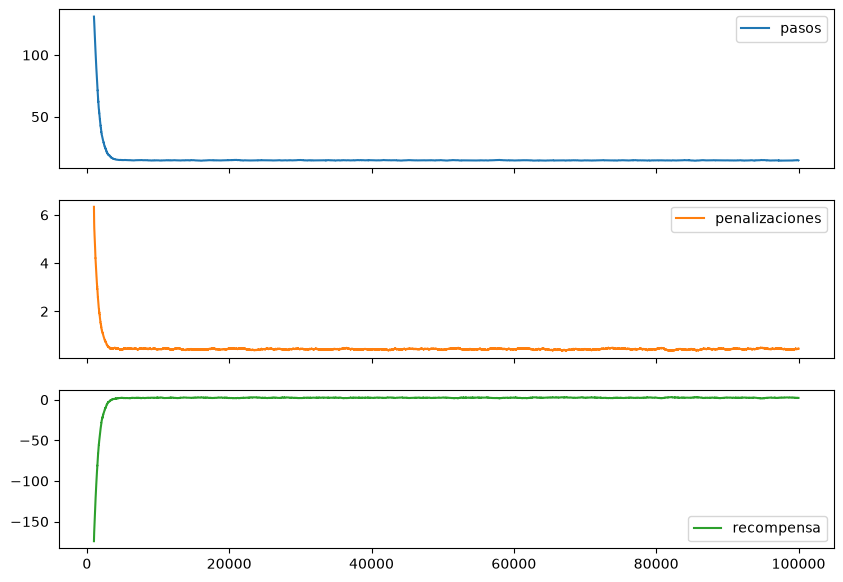

Entrenamiento completado: 100000 episodios


In [7]:
q_table,history=train_taxi(num_episodes,alpha,gamma,epsilon,SEED)
np.savez_compressed(cache_path(),q=q_table)
history.rolling(1000).mean().plot(subplots=True,figsize=(10,7));plt.show()
print('Entrenamiento completado:',num_episodes,'episodios')

Ahora que hemos estimado la tabla Q tras los 100,000 episodios, veamos cuáles son los valores Q en el estado de nuestra ilustración, que recordemos es el correspondiente al índice 328



In [8]:
display(pd.Series(q_table[328],index=['sur','norte','este','oeste','recoger','dejar']))

sur       -2.718651
norte      1.622615
este      -2.044455
oeste     -2.123683
recoger   -6.880770
dejar     -6.613922
dtype: float64

In [9]:
display(evaluate(q_table))

pasos/episodio             13.020000
penalizaciones/episodio     0.000000
recompensa/acción           0.612903
éxito                       1.000000
dtype: float64